In [154]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation

# Inhoud

1. [Introductie en specificaties](#1-introductie-en-specificaties)
2. [Ontwerp van de nokgeometrie](#geometrie)
3. [Inverse dynamica en nokveer](#3-inverse-dynamica-en-nokveer)
4. [Prestaties en verificatie](#4-prestaties-en-verificatie)
5. [Finale ontwerpwaarden en checklist](#5-finale-ontwerpwaarden-en-checklist)
6. [Referenties](#referenties)

<a id="intro"></a>
# 1. Introductie en Specificaties
## 1.1 Nokken-ontwerp: specificaties
Gegevens : De te ontwerpen nok moet volgende heffing kunnen realiseren :

1. van 45° tot 90° : +5 mm
2. van 90° tot 180° : +15 mm
3. van 180° tot 305° : -20 mm

De equivalente massa en dempingsconstante van de volger (en bijhorende onderdelen) worden respectievelijk geschat op 15 kg en 0.055, terwijl het mechanisme volgende statische krachten moet uitoefenen:

1. van 45° tot 90° : een konstante druk-kracht van 250 N
2. van 90° tot 180° : een lineair toenemende druk-kracht van 250 N tot 1050 N
3. van 180° tot 250° : een konstante trek-kracht van 300 N

De gevraagde cyclustijd voor de bewerking uitgevoerd door de volger is 0.3 sec.

Hieronder tonen we de gegeven specs in een grafiek van de positie en de kracht

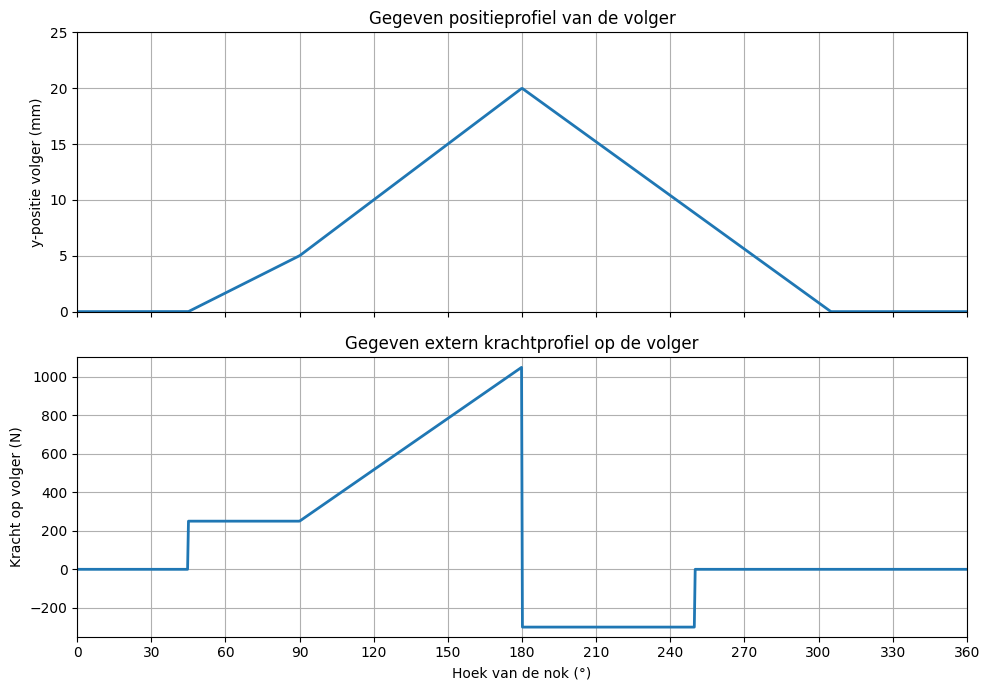

In [155]:
"""
Gegeven specificaties
"""

theta_given_deg = np.linspace(0, 360, 1000)   # hoek van de nok °

F_pre = 250    #N
F_max = 1050   #N
F_pull = -300  #N

theta_pull_end = 250 #°

"""
Positieprofiel y(theta)
"""
lift_given = np.zeros_like(theta_given_deg)

# 45°-90°: 0mm - 5mm
mask = (theta_given_deg >= 45) & (theta_given_deg < 90)
lift_given[mask] = (theta_given_deg[mask] - 45) / (90 - 45) * 5

# 90°-180°: 5mm - 20mm
mask = (theta_given_deg >= 90) & (theta_given_deg < 180)
lift_given[mask] = 5 + (theta_given_deg[mask] - 90) / (180 - 90) * 15

# 180°-305°: van 20mm - 0mm
mask = (theta_given_deg >= 180) & (theta_given_deg < 305)
lift_given[mask] = 20 - (theta_given_deg[mask] - 180) / (305 - 180) * 20

# 0°-45° en 305°-360° blijven 0mm

"""
Externe kracht F(theta)
"""
F = np.zeros_like(theta_given_deg)

# 45° - 90°: cte drukkracht
mask = (theta_given_deg >= 45) & (theta_given_deg < 90)
F[mask] = F_pre

# 90° - 180°: lineair stijgend van F_pre naar F_max
mask = (theta_given_deg >= 90) & (theta_given_deg < 180)
F[mask] = F_pre + (theta_given_deg[mask] - 90) / (180 - 90) * (F_max - F_pre)

# 180° - theta_pull_end: cte trekkracht
mask = (theta_given_deg >= 180) & (theta_given_deg < theta_pull_end)
F[mask] = F_pull

# Na theta_pull_end blijft de kracht 0 N

"""
# Grafieken
"""
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Grafiek 1: positie
axs[0].plot(theta_given_deg, lift_given, linewidth=2)
axs[0].set_ylabel("y-positie volger (mm)")
axs[0].set_title("Gegeven positieprofiel van de volger")
axs[0].set_xlim(0, 360)
axs[0].set_ylim(0, 25)
axs[0].set_yticks(np.arange(0, 26, 5))
axs[0].grid(True)

# Grafiek 2: kracht
axs[1].plot(theta_given_deg, F, linewidth=2)
axs[1].set_xlabel("Hoek van de nok (°)")
axs[1].set_ylabel("Kracht op volger (N)")
axs[1].set_title("Gegeven extern krachtprofiel op de volger")
axs[1].set_xlim(0, 360)
axs[1].set_ylim(-350, 1100)
axs[1].set_xticks(np.arange(0, 361, 30))
axs[1].grid(True)

plt.tight_layout()
plt.show()

## 1.2: Toepassing - Tablet Press

Op basis van het krachtenprofiel dachten we een soort stempelmachine te maken. Dit past goed bij een nokmechanisme, omdat de gewenste beweging periodiek is en omdat de kracht sterk afhankelijk is van de positie van de stempel .Omdat de krachten niet ongelofelijk hoog zijn was de toepassing tablet press voor de farmaseutische industrie boven gekomen. Hieronder is een schets van de verschillende stappen met daaronder uitleg.

<p align="center">
  <img src="Images\visualisatie_compressie.png" width="700"><br>
  <b>Figuur 1:</b> Visualie compressiestappen
</p>

#### Positie 1: Rust
*Hoeken: 305°-45°*

De stempel blijft zijn positie houden en ondervind geen externe krachten. Tijdens deze fase wordt de afgemaakte pil afgevoerd en een nieuwe matrijs gevuld met poeder klaargezet voor de volgende compressie.

#### Positie 2: Plaatsing stempel
*Hoek: $\theta_1$*

De stempel in rust is 2.5mm verwijderd van de opening van de matrijs. Van positie 1 naar positie 2 verplaatst de stempel dus +2.5mm zonder kracht te ondervinden. De reden dat deze hoek $\theta_1$ wordt genoemd is omdat uiteindelijk het verplaatsingsprofiel wordt verzacht om minder sterke schokken te krijgen (deze moet dus berekend worden).

#### Positie 3: Indrukken stempel
*Hoek: 90°*

De stempel positioneert zich 2.5mm in de matrijs (afmaken van 5mm verplaatsing). Binnen de matrijs in de neerwaarste slag zal de stempel een constante tegenwerkende wrijving [1](#ref1) van 250N ondervinden (daarom dat van 1 $\rightarrow$ 3 opgesplitst moest worden). De kleine compressie van de poeder die hier gebeurt wordt verwaarloosd.

#### Positie 4: Compressie + Dwell
*Hoeken: 150°-180°*

Van 90°-150° is de compressieslag van de stempel waar de stempel 15mm in de matrijs wordt geduwd. Compressie wordt gemodelleerd als evenredig met de samendrukking en dus lineair toenemend tot 1050N. Hierbovenop wordt de wrijving in de matrijs gesuperponeerd.

Van 150°-180° blijft de stempel op dezelfde positie. Dit heet dwelling en zorgt ervoor dat er minder kans is op barsten in de pil [2](#ref2),[3](#ref3). In deze positie ondervind de stempel altijd dezelfde kracht van 1050N.

#### Positie 5: Uittrekken
*Hoek: $\theta_2$*

Van 180°-$\theta_2$ wordt de stempel 17.5mm uitgetrokken. Op deze positie is de stempel net uit de matrijs en tot dan ondervindt het een tegenwerkende kracht van -300N.

#### Positie 6: Terug naar startpositie
*Hoek: 305°*

De stempel verplaatst de laatste 2.5mm terug naar de startpositie. Tijdens deze beweging ondervindt de stempel geen uitwendige kracht.

### Verschillen met gegeven positie- en krachtprofielen:
Ten opzichte van de oorspronkelijke specificatie voegen we dus vooral een duidelijkere compressiefase en een dwell op maximale lift toe. Hierdoor sluit het bewegingsprofiel beter aan bij de gekozen toepassing.

### Vergelijking met commerciele tablet press:
[4](#ref4), [5](#ref5), [6](#ref6)

<div style="display: flex; justify-content: center; margin-top: 1rem;">
    <img src=""
         style="max-width: 600px; width: 100%; height: auto; border: 0;" />
</div>
<div style="display: flex; gap: 25px; align-items: flex-start;">
  <figure style="width: 38%; text-align: center;">
    <img src="Images/Tablet_press_animation.gif" style="width: 100%;">
    <figcaption><b>Figuur:</b> Animatie van compressiestappen commerciele tablet press.</figcaption>
  </figure>

  <figure style="width: 28%; text-align: center;">
    <img src="Images\pill-maker-machine.webp" style="width: 100%;">
    <figcaption><b>Figuur:</b> Foto commerciele tablet press.</figcaption>
  </figure>
</div>


## 1.3: Keuze van de bewegingswetten

Voor de vrije verplaatsing en de eerste intrede in de matrijs wordt een cycloïdale bewegingswet gebruikt. Deze bewegingswet heeft een nulwaarde voor snelheid en versnelling aan het begin en einde van het segment. Daardoor wordt de overgang tussen rust en beweging vloeiender dan bij een lineair profiel. Dit is belangrijk omdat plotse versnellingen trillingen kunnen veroorzaken, wat nadelig is voor een gelijkmatige poederverdeling in de matrijs.

Voor de hoofdcompressie wordt een 7de-graads polynoom gebruikt. Dit segment is het meest kritisch, omdat hier de grootste krachten optreden en de tablet effectief gevormd wordt. De 7de-graads polynoom zorgt ervoor dat positie, snelheid, versnelling en jerk op een gecontroleerde manier naar nul kunnen gaan aan de grenzen van het segment. Hierdoor worden schokken en abrupte veranderingen in de dynamische belasting beperkt.

Tussen 150° en 180° wordt een dwell voorzien. Tijdens deze fase blijft de stempel op maximale indrukking staan. Dit laat toe om de maximale compressiekracht gedurende een korte tijd aan te houden, wat de kwaliteit en vormvastheid van de tablet kan verbeteren.

Voor de terugtrekkende beweging wordt opnieuw een cycloïdale bewegingswet gebruikt. Deze beweging is minder kritisch dan de hoofdcompressie, maar moet nog steeds voldoende vloeiend verlopen om beschadiging van de gevormde tablet te vermijden. De laatste verplaatsing terug naar de startpositie gebeurt opnieuw zonder externe kracht.

<div style=" display: grid; place-items: center; place-content: center;">
 <img style="border: 0; display: inline-block;" height="100%"
      src="images/motion-law-summary.png">
     <figcaption>Figuur: Samenvatting bewegingswetten</figcaption>
</div>

In [156]:
dtheta = 0.01          # resolutie in °
T = 0.3                # s
omega = 2 * np.pi / T  # hoeksnelheid rad/s

theta_deg = np.arange(0, 360, dtheta)   # hoek °
theta = theta_deg * np.pi / 180         # hoek rad

lift = np.zeros_like(theta_deg)         # positie mm
vel_deg = np.zeros_like(theta_deg)      # snelheid mm/deg
acc_deg = np.zeros_like(theta_deg)      # versnelling mm/deg²
jerk_deg = np.zeros_like(theta_deg)     # jerk mm/deg³
ext_load = np.zeros_like(theta_deg)     # externe kracht [N]
pressure_angle = np.zeros_like(theta_deg)

# Bewegingswetten

def motion_law(u, law):
    """
    Geeft positie q, snelheid dq, versnelling ddq en jerk dddq
    i.f.v. u = (theta - theta_start) / beta.
    Afgeleiden naar u.
    """
    if law == 1:  # dwell
        q = np.zeros_like(u)
        dq = np.zeros_like(u)
        ddq = np.zeros_like(u)
        dddq = np.zeros_like(u)
    elif law == 6:  # cycloïde
        q = u - np.sin(2 * np.pi * u) / (2 * np.pi)
        dq = 1 - np.cos(2 * np.pi * u)
        ddq = 2 * np.pi * np.sin(2 * np.pi * u)
        dddq = 4 * np.pi**2 * np.cos(2 * np.pi * u)
    elif law == 7:  # 5de-graads polynoom
        q = 10*u**3 - 15*u**4 + 6*u**5
        dq = 30*u**2 - 60*u**3 + 30*u**4
        ddq = 60*u - 180*u**2 + 120*u**3
        dddq = 60 - 360*u + 360*u**2
    elif law == 9:  # 7de-graads polynoom
        q = 35*u**4 - 84*u**5 + 70*u**6 - 20*u**7
        dq = 140*u**3 - 420*u**4 + 420*u**5 - 140*u**6
        ddq = 420*u**2 - 1680*u**3 + 2100*u**4 - 840*u**5
        dddq = 840*u - 5040*u**2 + 8400*u**3 - 4200*u**4
    else:
        raise ValueError(f"Onbekende bewegingswet: {law}")
    return q, dq, ddq, dddq

def add_motion_segment(startangle, endangle, startlift, endlift, motionlaw):
    """
    Vult lift, vel_deg, acc_deg en jerk_deg voor bewegingssegment.
    Variabelen bruikbaar in de rest van de notebook.
    """
    assert endangle > startangle, "End angle should be bigger"

    mask = (theta_deg >= startangle) & (theta_deg < endangle)

    beta = endangle - startangle
    L = endlift - startlift

    u = (theta_deg[mask] - startangle) / beta
    q, dq, ddq, dddq = motion_law(u, motionlaw)

    lift[mask] = startlift + L * q
    vel_deg[mask] = L / beta * dq
    acc_deg[mask] = L / beta**2 * ddq
    jerk_deg[mask] = L / beta**3 * dddq


def find_theta_at_lift(startangle, endangle, target_lift):
    """
    Zoek hoek waarbij lift in segment target_lift is.
    Werkt voor stijgende en dalende beweging.
    """
    mask = (theta_deg >= startangle) & (theta_deg < endangle)

    th = theta_deg[mask]
    y = lift[mask]

    crossings = np.where((y[:-1] - target_lift) * (y[1:] - target_lift) <= 0)[0]

    if len(crossings) == 0:
        raise ValueError(
            f"Lift {target_lift} mm wordt niet bereikt tussen {startangle}° en {endangle}°"
        )

    i = crossings[0]

    # lineaire interpolatie tussen twee dichtstbijzijnde punten
    theta_crossing = th[i] + (target_lift - y[i]) * (th[i+1] - th[i]) / (y[i+1] - y[i])

    return theta_crossing

In [157]:
# Segmenten van het aangepast positieprofiel
startangle1 = 0
endangle1 = 45
theta_seg1 = endangle1 - startangle1
startlift1 = 0
endlift1 = 0
motionlaw1 = 1      # dwell

startangle2 = 45
endangle2 = 90
theta_seg2 = endangle2 - startangle2
startlift2 = 0
endlift2 = 5
motionlaw2 = 6      # cycloïde

startangle3 = 90
endangle3 = 150
theta_seg3 = endangle3 - startangle3
startlift3 = 5
endlift3 = 20
motionlaw3 = 9      # 7de-graads polynoom

startangle4 = 150
endangle4 = 180
theta_seg4 = endangle4 - startangle4
startlift4 = 20
endlift4 = 20
motionlaw4 = 1      # dwell

startangle5 = 180
endangle5 = 305
theta_seg5 = endangle5 - startangle5
startlift5 = 20
endlift5 = 0
motionlaw5 = 6      # cycloïde

startangle6 = 305
endangle6 = 360
theta_seg6 = endangle6 - startangle6
startlift6 = 0
endlift6 = 0
motionlaw6 = 1      # dwell

motion_segments = [
    (startangle1, endangle1, startlift1, endlift1, motionlaw1),
    (startangle2, endangle2, startlift2, endlift2, motionlaw2),
    (startangle3, endangle3, startlift3, endlift3, motionlaw3),
    (startangle4, endangle4, startlift4, endlift4, motionlaw4),
    (startangle5, endangle5, startlift5, endlift5, motionlaw5),
    (startangle6, endangle6, startlift6, endlift6, motionlaw6),
]

for segment in motion_segments:
    add_motion_segment(*segment)

# afgeleiden naar radialen
vel = vel_deg * 180 / np.pi
acc = acc_deg * (180 / np.pi)**2
jerk = jerk_deg * (180 / np.pi)**3

# echte tijdsafgeleiden
vel_time = vel * omega
acc_time = acc * omega**2
jerk_time = jerk * omega**3

In [158]:
# Bepaal theta1 en theta2 uit gesmoothde positieprofiel

# theta1 - stempel raakt de opening matrijs bij y = 2.5 mm
theta1 = find_theta_at_lift(45, 90, 2.5)

# theta2 - stempel net uit matrijs bij y = 2.5 mm
theta2 = find_theta_at_lift(180, 305, 2.5)

print(f"theta1 = {theta1:.2f}°")
print(f"theta2 = {theta2:.2f}°")

theta1 = 67.50°
theta2 = 269.86°


In [159]:
# Aangepast krachtenprofiel

def add_load_segment(startangle, endangle, startload, endload):
    """
    Vult ext_load voor krachtsegment.
    Kracht verloopt lineair van startload naar endload.
    """
    if np.isclose(startangle, endangle):
        return

    mask = (theta_deg >= startangle) & (theta_deg < endangle)

    u = (theta_deg[mask] - startangle) / (endangle - startangle)
    ext_load[mask] = startload + u * (endload - startload)

# Van 45° - theta1 geen externe kracht
startangleload1 = theta1
endangleload1 = 90
startload1 = 250
endload1 = 250

startangleload2 = 90
endangleload2 = 150
startload2 = 250
endload2 = 1050

startangleload3 = 150
endangleload3 = 180
startload3 = 1050
endload3 = 1050

startangleload4 = 180
endangleload4 = theta2
startload4 = -300
endload4 = -300

load_segments = [
    (startangleload1, endangleload1, startload1, endload1),
    (startangleload2, endangleload2, startload2, endload2),
    (startangleload3, endangleload3, startload3, endload3),
    (startangleload4, endangleload4, startload4, endload4),
]

for segment in load_segments:
    add_load_segment(*segment)

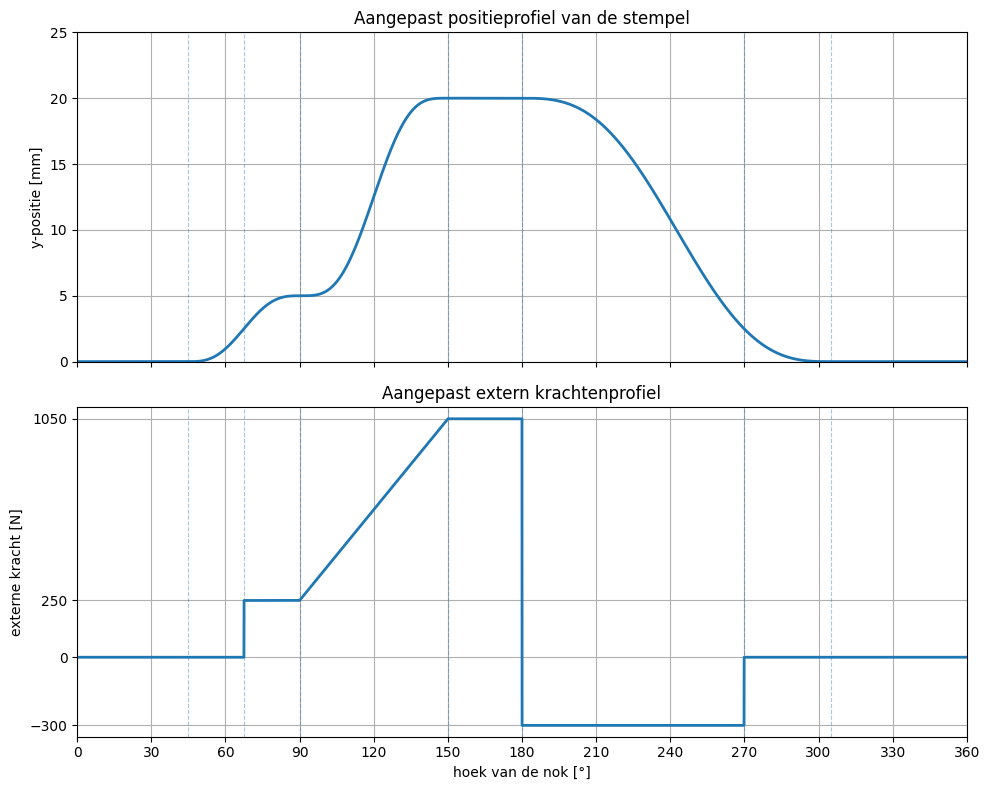

In [160]:
# vergelijkende grafieken: positie, kracht

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
key_angles = [45, theta1, 90, 150, 180, theta2, 305]

# Positie
axs[0].plot(theta_deg, lift, linewidth=2)
axs[0].set_ylabel("y-positie [mm]")
axs[0].set_title("Aangepast positieprofiel van de stempel")
axs[0].set_ylim(0, 25)
axs[0].set_yticks(np.arange(0, 26, 5))
axs[0].grid(True)

# Kracht
axs[1].plot(theta_deg, ext_load, linewidth=2)
axs[1].set_ylabel("externe kracht [N]")
axs[1].set_xlabel("hoek van de nok [°]")
axs[1].set_title("Aangepast extern krachtenprofiel")
axs[1].set_ylim(-350, 1100)
axs[1].set_yticks([-300, 0, 250, 1050])
axs[1].grid(True)

# Gemeenschappelijke x-as en verticale hulplijnen
for ax in axs:
    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 30))

    for angle in key_angles:
        ax.axvline(angle, linestyle="--", linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

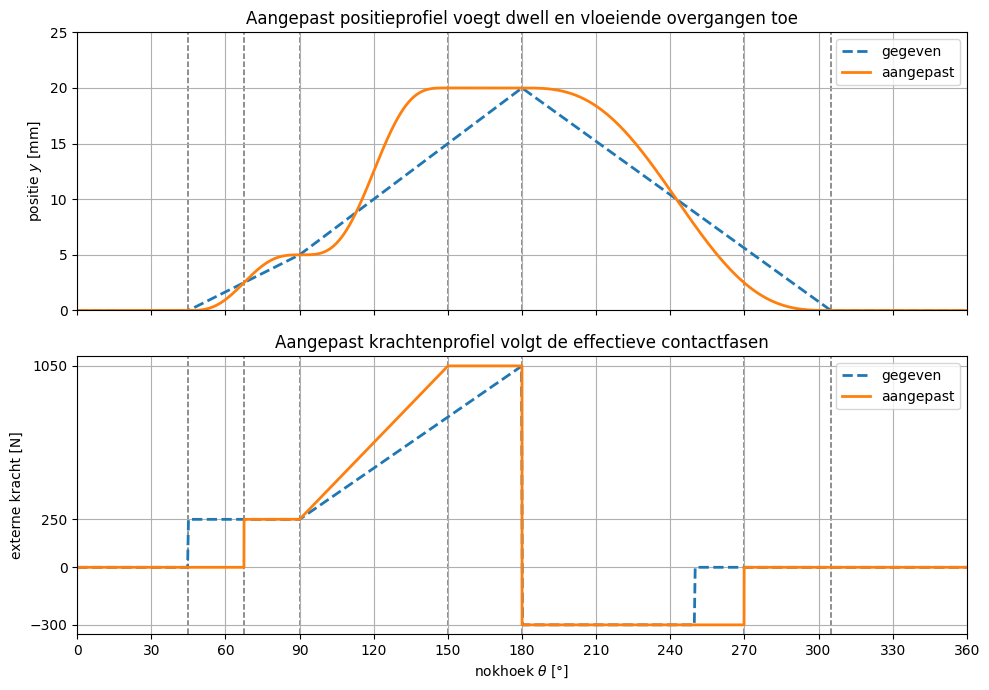

In [161]:
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
key_angles = [45, theta1, 90, 150, 180, theta2, 305]

axs[0].plot(theta_given_deg, lift_given, linewidth=2, linestyle="--", label="gegeven")
axs[0].plot(theta_deg, lift, linewidth=2, label="aangepast")
axs[0].set_ylabel("positie $y$ [mm]")
axs[0].set_title("Aangepast positieprofiel voegt dwell en vloeiende overgangen toe")
axs[0].set_ylim(0, 25)
axs[0].set_yticks(np.arange(0, 26, 5))
axs[0].legend()
axs[0].grid(True)

axs[1].plot(theta_given_deg, F, linewidth=2, linestyle="--", label="gegeven")
axs[1].plot(theta_deg, ext_load, linewidth=2, label="aangepast")
axs[1].set_ylabel("externe kracht [N]")
axs[1].set_xlabel("nokhoek $\\theta$ [°]")
axs[1].set_title("Aangepast krachtenprofiel volgt de effectieve contactfasen")
axs[1].set_ylim(-350, 1100)
axs[1].set_yticks([-300, 0, 250, 1050])
axs[1].legend()
axs[1].grid(True)

for ax in axs:
    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 30))
    for angle in key_angles:
        ax.axvline(angle, linestyle="--", linewidth=1.1, alpha=0.75, color="0.25", zorder=0)

plt.tight_layout()
plt.show()

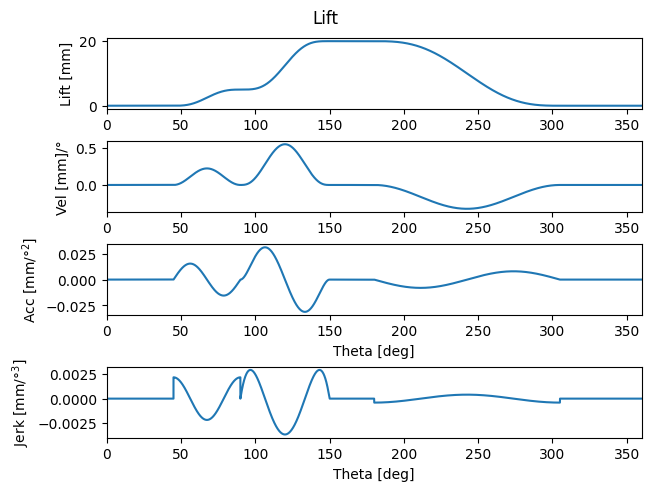

In [162]:
# Grafieken: positie, snelheid, versnelling, jerk

def plotMotionLaw(t,lift,vel,acc,jerk):
    fig1, ax1 = plt.subplots(nrows=4,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/°")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/$°^2$]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])

    ax1[3].plot(t, jerk)
    ax1[3].set_ylabel("Jerk [mm/$°^3$]")
    ax1[3].set_xlabel('Theta [deg]')
    ax1[3].set_xlim([0,360])

plotMotionLaw(theta_deg,lift,vel_deg,acc_deg, jerk_deg)
plt.show()

**Interpretatie grafieken:** Het aangepaste profiel bestaat uit een rustige intrede, een hoofdcompressie, een dwell op maximale lift en een gecontroleerde terugkeer. De positie, snelheid en versnelling blijven overal eindig en zijn continu op de segmentgrenzen. De jerk vertoont wel discontinuiteiten aan sommige overgangen tussen bewegingswetten. Dit is een gevolg van het stukgewijs opbouwen van het profiel. Voor dit eerste ontwerp is dat aanvaardbaar, omdat er geen sprongen optreden in positie of snelheid en de versnellingen beperkt blijven. Een nog vloeiender profiel zou mogelijk zijn door extra overgangssegmenten of hogere-orde polynomen te gebruiken, maar dat zou het ontwerp complexer maken.

## 1.4: Ontwerpdoelen
Uit de toepassing volgen de volgende ontwerpdoelen:

| Doel | Betekenis voor het ontwerp |
|---|---|
| Contact behouden | De normaalkracht tussen nok en volger moet positief blijven. |
| Drukhoek beperken | Een te grote drukhoek veroorzaakt grote zijdelingse krachten en meer wrijving. |
| Ondersnijding vermijden | De nokcontour moet geometrisch realiseerbaar blijven. |
| Wrijving beperken | De excentriciteit en geometrie worden gekozen om wrijvingsverlies te beperken. |
| Vermogenspieken beperken | Het ontwerp moet geen onnodig grote piekvermogens vragen. |

<a id="geometrie"></a>
# 2. Ontwerp van de nokgeometrie

## 2.1 Ontwerpaanpak

Voor het ontwerp van de nokgeometrie gebruiken we de Kloomok-Muffley-aanpak. In de onze implementatie is het opgesplitst in kleinere functies zodat berekening en visualisatie gescheiden blijven. Hierbij wordt eerst de grootte van de pitch radius $R_0$ gekozen op basis van de drukhoek. Daarna wordt gecontroleerd of de gekozen rolvolgerstraal $R_r$ geen ondersnijding veroorzaakt. Ten slotte wordt de effectieve nokcontour opgesteld.

De volgorde van het ontwerp is:

1. keuze van $R_0$ op basis van de maximale drukhoek;
2. keuze van $R_r$ op basis van ondersnijding;
3. bepaling van de basisstraal $R_b = R_0 - R_r$;
4. controle van drukhoek en kromtestraal over de volledige rotatie;
5. constructie van de nokcontour.

De excentriciteit wordt later gebruikt als optimalisatieparameter in de dynamische analyse met wrijving. In dit geometriegedeelte gebruiken we dus $e = 0$.

In [163]:
# Kloomok-Muffley hulpfuncties voor geometrieontwerp

alpha_limit = 35  # graden

geometry_segments = [
    ("Intrede", startangle2, endangle2, startlift2, endlift2, motionlaw2),
    ("Hoofdcompressie", startangle3, endangle3, startlift3, endlift3, motionlaw3),
    ("Terugkeer", startangle5, endangle5, startlift5, endlift5, motionlaw5),
]

def kloomok_segment_profile(startangle, endangle, startlift, endlift, motionlaw, n=1000):
    """
    maakt y, y', y'' voor segment
    """
    beta_deg = endangle - startangle # cam angle interval of the segment
    beta_rad = np.deg2rad(beta_deg)
    L = endlift - startlift

    u = np.linspace(0, 1, n)
    q, dq, ddq, dddq = motion_law(u, motionlaw)

    y = startlift + L * q
    dy_dtheta = L / beta_rad * dq
    d2y_dtheta2 = L / beta_rad**2 * ddq

    return u, y, dy_dtheta, d2y_dtheta2


def kloomok_pressure_angle_scan(startangle, endangle, startlift, endlift, motionlaw,
                                R0_values, eccentricity=0):
    """
    berekent max. drukhoek i.f.v. R0
    """
    _, y, dy_dtheta, _ = kloomok_segment_profile(
        startangle, endangle, startlift, endlift, motionlaw
    )

    alpha_max = []

    for R0_candidate in R0_values:
        d = np.sqrt(R0_candidate**2 - eccentricity**2)
        alpha = np.arctan((dy_dtheta - eccentricity) / (d + y))
        alpha_max.append(np.max(np.abs(np.rad2deg(alpha))))

    return np.array(alpha_max)


def kloomok_curvature_scan(startangle, endangle, startlift, endlift, motionlaw, R0_values):
    """
    berekent minimale kromtestraal i.f.v. R0
    """
    _, y, dy_dtheta, d2y_dtheta2 = kloomok_segment_profile(
        startangle, endangle, startlift, endlift, motionlaw
    )

    rho_min = []

    for R0_candidate in R0_values:
        R = R0_candidate + y

        rho = ((R**2 + dy_dtheta**2)**1.5) / (
            R**2 + 2*dy_dtheta**2 - R*d2y_dtheta2
        )

        rho = rho[np.isfinite(rho)]
        rho = rho[rho > 0]

        rho_min.append(np.min(rho) if len(rho) > 0 else np.nan)

    return np.array(rho_min)

""""
De formules komen uit de Kloomok-Muffley-methode. 
We hebben de functie opgesplitst zodat we drukhoek, 
ondersnijding en finale validatie apart kunnen tonen.
"""


'"\nDe formules komen uit de Kloomok-Muffley-methode. \nWe hebben de functie opgesplitst zodat we drukhoek, \nondersnijding en finale validatie apart kunnen tonen.\n'

## 2.2 Pitch radius, rolvolgerstraal en basisstraal

De pitch radius $R_0$ is de afstand van het middelpunt van de nok tot het middelpunt van de volger bij nul lift. Omdat de rolvolger zelf een straal $R_r$ heeft, geldt:
$$
R_b = R_0 - R_r
$$
Een grotere $R_0$ verlaagt meestal de drukhoek en verkleint de kans op ondersnijding, maar maakt de nok groter. Een grotere rolvolger verlaagt de contactspanningen, maar vergroot de kans op ondersnijding omdat de effectieve nokcontour sterker afgerond moet worden.

In [164]:
R0 = 80       # mm, pitch radius
Rr = 35       # mm, rolvolgerstraal
base_radius = R0 - Rr
eccentricity_geometry = 0

print(f"Pitch radius R0:    {R0:.1f} mm")
print(f"Rolvolgerstraal Rr: {Rr:.1f} mm")
print(f"Basisstraal Rb:     {base_radius:.1f} mm")

Pitch radius R0:    80.0 mm
Rolvolgerstraal Rr: 35.0 mm
Basisstraal Rb:     45.0 mm


Voor het basisontwerp kiezen we $R_0 = 80$ mm en $R_r = 35$ mm. Daardoor wordt de basisstraal $R_b = 45$ mm. In de rest van dit deel controleren we of deze keuze voldoet voor drukhoek en ondersnijding.

## 2.3 Drukhoek

De drukhoek $\alpha$ bepaalt hoeveel zijdelingse kracht er op de volgergeleiding komt. Een te grote drukhoek verhoogt de wrijving en maakt de beweging minder efficiënt. Daarom gebruiken we als ontwerpvoorwaarde:
$$
|\alpha|_\text{max} < 35^\circ
$$
Met de Kloomok-Muffley-aanpak berekenen we voor elk bewegend segment hoe groot $R_0$ minstens moet zijn om onder deze limiet te blijven.

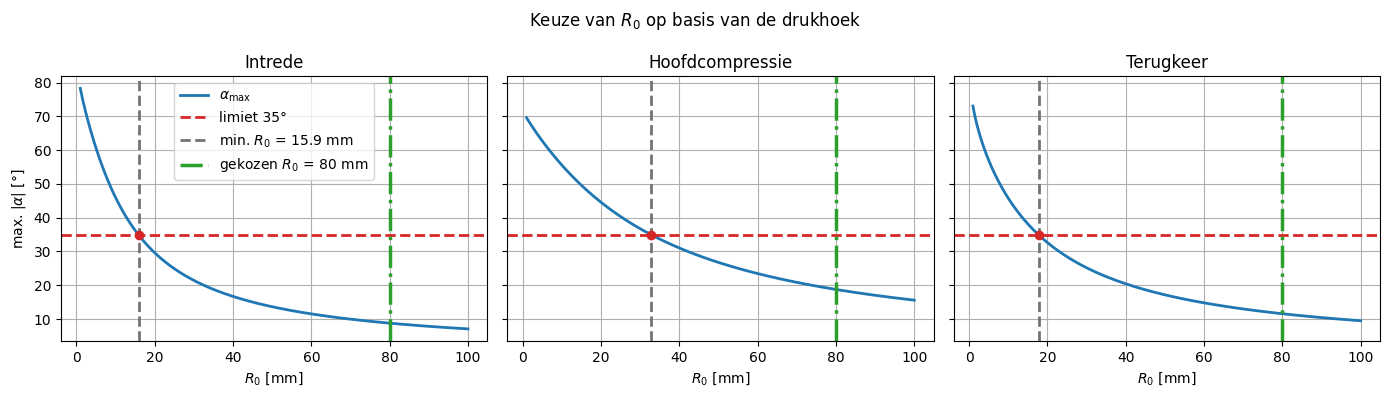

Intrede: minimale R0 volgens drukhoekcriterium |alpha| < 35° = 15.9 mm
Hoofdcompressie: minimale R0 volgens drukhoekcriterium |alpha| < 35° = 32.8 mm
Terugkeer: minimale R0 volgens drukhoekcriterium |alpha| < 35° = 17.8 mm


In [165]:
R0_scan_min = 1
R0_scan_max = 100 
R0_delta = 0.1 
R0_values = np.arange(R0_scan_min, R0_scan_max + R0_delta, R0_delta) 

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

required_R0 = {}

for ax, (name, startangle, endangle, startlift, endlift, motionlaw) in zip(axs, geometry_segments):
    alpha_max = kloomok_pressure_angle_scan(
        startangle, endangle, startlift, endlift, motionlaw,
        R0_values,
        eccentricity=eccentricity_geometry
    )

    ok = np.where(alpha_max <= alpha_limit)[0]
    R0_required = R0_values[ok[0]] if len(ok) > 0 else np.nan
    required_R0[name] = R0_required

    ax.plot(R0_values, alpha_max, linewidth=2, label=r"$\alpha_\mathrm{max}$")
    ax.axhline(alpha_limit, linestyle="--", linewidth=2, color="tab:red", label="limiet 35°")
    ax.axvline(R0_required, linestyle="--", linewidth=2, color="0.45", label=f"min. $R_0$ = {R0_required:.1f} mm")
    ax.axvline(R0, linestyle="-.", linewidth=2.5, color="tab:green", label=f"gekozen $R_0$ = {R0:.0f} mm")
    ax.scatter(R0_required, alpha_limit, color="tab:red", zorder=5)

    ax.set_title(name)
    ax.set_xlabel("$R_0$ [mm]")
    ax.grid(True)

axs[0].set_ylabel("max. $|\\alpha|$ [°]")
axs[0].legend()

plt.suptitle("Keuze van $R_0$ op basis van de drukhoek")
plt.tight_layout()
plt.show()

for name, R0_required in required_R0.items():
    print(f"{name}: minimale R0 volgens drukhoekcriterium |alpha| < 35° = {R0_required:.1f} mm")

De hoofdcompressie is bepalend voor de drukhoek en vraagt de grootste minimale $R_0$. De waarden uit deze grafiek zijn minimale waarden op basis van alleen het drukhoekcriterium. We kiezen $R_0 = 80$ mm voor extra een marge en om ondersnijding te vermijden.

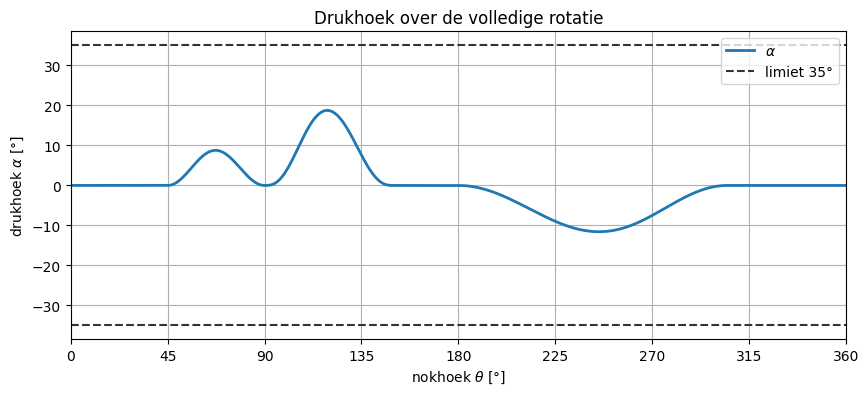

Maximale drukhoek: 18.76°


In [166]:
def calculate_pressure_angle(vel, eccentricity, R0, lift):
    d = np.sqrt(R0**2 - eccentricity**2)
    return np.arctan((vel - eccentricity) / (d + lift))

pressure_angle_geometry = calculate_pressure_angle(
    vel,
    eccentricity_geometry,
    R0,
    lift
)

plt.figure(figsize=(10, 4))
plt.plot(theta_deg, np.rad2deg(pressure_angle_geometry), linewidth=2, label="$\\alpha$")
plt.axhline(alpha_limit, linestyle="--", linewidth=1.5, color="0.2", label="limiet 35°")
plt.axhline(-alpha_limit, linestyle="--", linewidth=1.5, color="0.2")
plt.xlabel("nokhoek $\\theta$ [°]")
plt.ylabel("drukhoek $\\alpha$ [°]")
plt.title("Drukhoek over de volledige rotatie")
plt.xlim(0, 360)
plt.xticks(np.arange(0, 361, 45))
plt.grid(True)
plt.legend()
plt.show()

print(f"Maximale drukhoek: {np.max(np.abs(np.rad2deg(pressure_angle_geometry))):.2f}°")

## 2.4 Kromtestraal en ondersnijding

Na de keuze van $R_0$ controleren we de rolvolgerstraal $R_r$. Ondersnijding treedt op wanneer de rolvolger te groot is ten opzichte van de lokale kromtestraal van de pitch curve. Daarom moet gelden:

$$
\rho_{\text{pitch,min}} > R_r
$$

waarbij $\rho_{\text{pitch,min}}$ de minimale positieve kromtestraal van de pitch curve is:

$$ \rho =
 \frac{\left [ R^2 + (f'(\theta))^2 \right ]^{\frac{3}{2}}}
      {R^2 + 2(f'(\theta))^2 - R\, f''(\theta)},
\quad \text{met } R= R_0 +f(\theta).
$$

In [167]:
def kloomok_follower_radius_vs_beta(R0, target_beta, startlift, endlift, motionlaw, beta_values):
    """
    Berekent rho_pitch,min als functie van de segmenthoek beta.
    R0 blijft vast. Dit volgt de Kloomok-Muffley-controle voor ondersnijding.
    """
    rho_min_values = []

    for beta_deg in beta_values:
        beta_rad = np.deg2rad(beta_deg)
        L = endlift - startlift

        x = np.linspace(0, 1, 1000)
        y_norm, dy_norm, ddy_norm, _ = motion_law(x, motionlaw)

        y = startlift + L * y_norm
        dy_dtheta = L / beta_rad * dy_norm
        d2y_dtheta2 = L / beta_rad**2 * ddy_norm

        R = R0 + y
        numerator = (R**2 + dy_dtheta**2)**1.5
        denominator = R**2 + 2*dy_dtheta**2 - R*d2y_dtheta2

        with np.errstate(divide="ignore", invalid="ignore"):
            rho = numerator / denominator

        rho = rho[np.isfinite(rho)]
        rho = rho[rho > 0]

        rho_min_values.append(np.min(rho) if len(rho) > 0 else np.nan)

    rho_min_values = np.array(rho_min_values)

    rho_at_target = np.interp(target_beta, beta_values, rho_min_values)

    return rho_min_values, rho_at_target

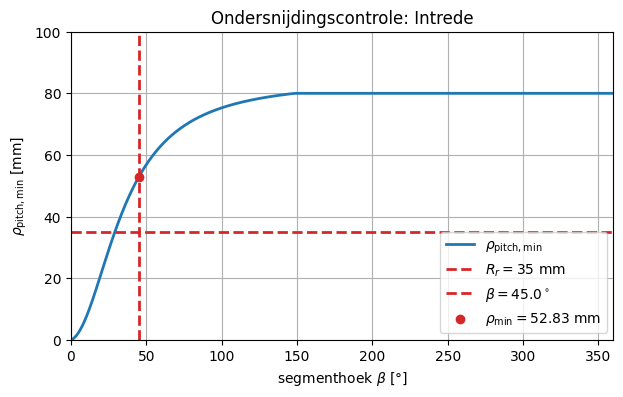

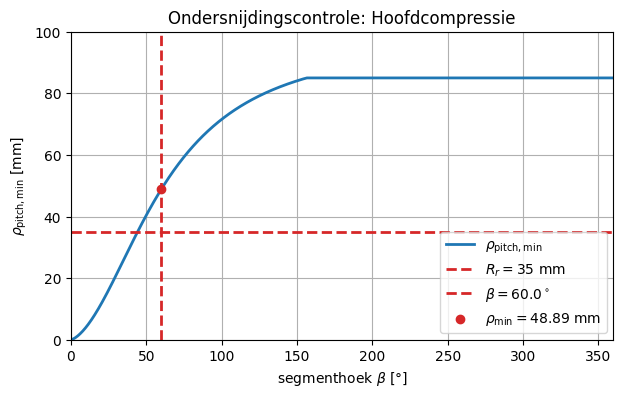

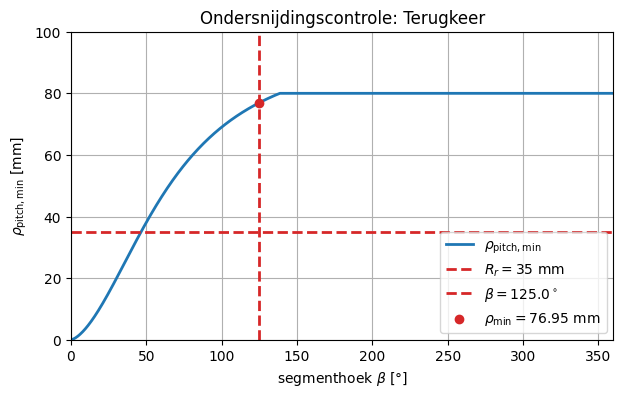

In [172]:
for name, beta_design, startlift, endlift, motionlaw in curvature_segments:
    rho_min_values, rho_design = kloomok_follower_radius_vs_beta(
        R0,
        beta_design,
        startlift,
        endlift,
        motionlaw,
        beta_values
    )

    plt.figure(figsize=(7, 4))
    plt.plot(beta_values, rho_min_values, linewidth=2, label="$\\rho_{\\mathrm{pitch,min}}$")
    plt.axhline(Rr, linestyle="--", linewidth=2, color="tab:red", label=f"$R_r = {Rr:.0f}$ mm")
    plt.axvline(beta_design, linestyle="--", linewidth=2, color="tab:red", label=f"$\\beta = {beta_design:.1f}^\\circ$")
    plt.scatter(beta_design, rho_design, color="tab:red", zorder=5,
                label=f"$\\rho_{{\\mathrm{{min}}}} = {rho_design:.2f}$ mm")

    plt.xlabel("segmenthoek $\\beta$ [°]")
    plt.ylabel("$\\rho_{\\mathrm{pitch,min}}$ [mm]")
    plt.title(f"Ondersnijdingscontrole: {name}")
    plt.xlim(0, max(360, beta_design + 30))
    plt.ylim(0, max(100, rho_design + 20))
    plt.grid(True)
    plt.legend()
    plt.show()

Voor alle bewegende segmenten ligt de minimale positieve kromtestraal van de pitch curve boven de gekozen rolvolgerstraal $R_r = 35$ mm. Daardoor wordt ondersnijding vermeden. De hoofdcompressie blijft het meest kritisch, omdat daar de kromming het sterkst varieert.

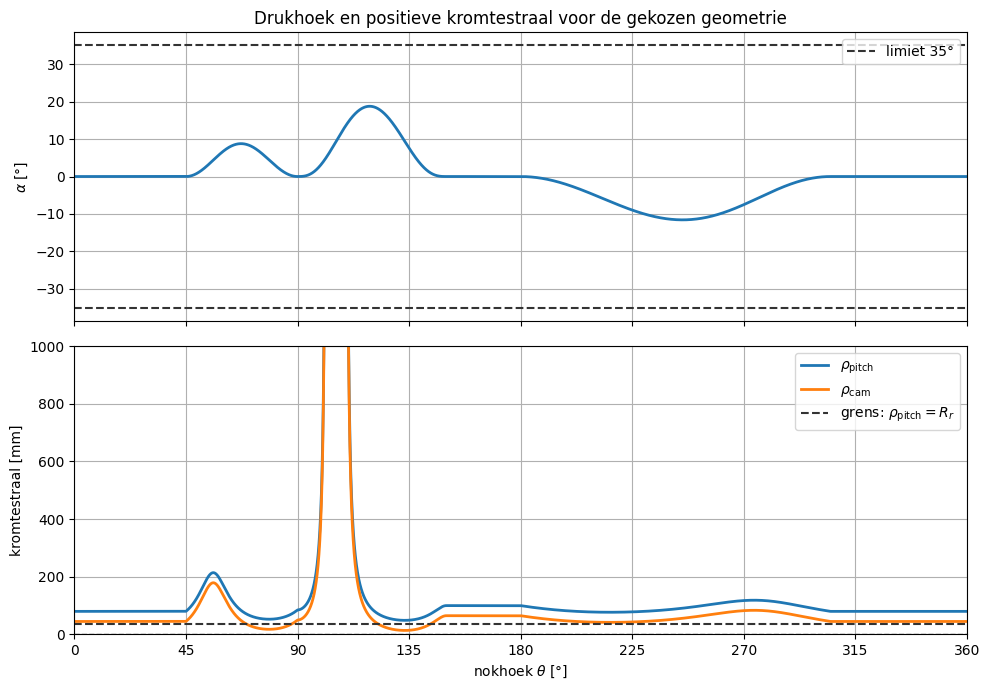

Minimale positieve rho_pitch: 48.89 mm
Minimale positieve rho_cam:   13.89 mm


In [169]:
rho_pitch_geometry = calculate_radius_curvature_pitch(R0, lift, vel, acc)
rho_cam_geometry = rho_pitch_geometry - Rr

# Enkel positieve en relevante waarden tonen
rho_pitch_plot = rho_pitch_geometry.copy()
rho_cam_plot = rho_cam_geometry.copy()

rho_pitch_plot[(rho_pitch_plot <= 0) | (rho_pitch_plot > 1000)] = np.nan
rho_cam_plot[(rho_cam_plot <= 0) | (rho_cam_plot > 1000)] = np.nan

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axs[0].plot(theta_deg, np.rad2deg(pressure_angle_geometry), linewidth=2)
axs[0].axhline(alpha_limit, linestyle="--", linewidth=1.5, color="0.2", label="limiet 35°")
axs[0].axhline(-alpha_limit, linestyle="--", linewidth=1.5, color="0.2")
axs[0].set_ylabel("$\\alpha$ [°]")
axs[0].set_title("Drukhoek en positieve kromtestraal voor de gekozen geometrie")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(theta_deg, rho_pitch_plot, linewidth=2, label="$\\rho_\\mathrm{pitch}$")
axs[1].plot(theta_deg, rho_cam_plot, linewidth=2, label="$\\rho_\\mathrm{cam}$")
axs[1].axhline(Rr, linestyle="--", linewidth=1.5, color="0.2", label="grens: $\\rho_\\mathrm{pitch} = R_r$")
axs[1].axhline(0, linestyle="--", linewidth=1.0, color="0.4")
axs[1].set_xlabel("nokhoek $\\theta$ [°]")
axs[1].set_ylabel("kromtestraal [mm]")
axs[1].set_ylim(0, 1000)
axs[1].grid(True)
axs[1].legend()

for ax in axs:
    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 45))

plt.tight_layout()
plt.show()

print(f"Minimale positieve rho_pitch: {np.nanmin(rho_pitch_geometry[rho_pitch_geometry > 0]):.2f} mm")
print(f"Minimale positieve rho_cam:   {np.nanmin(rho_cam_geometry[rho_cam_geometry > 0]):.2f} mm")

Het asymptotisch gedrag van de kromtestraal komt doordat de pitch curve lokaal door een punt gaat waar de kromming zeer klein wordt of van teken verandert. De curve is daar lokaal bijna recht of gaat over van convex naar concaaf.

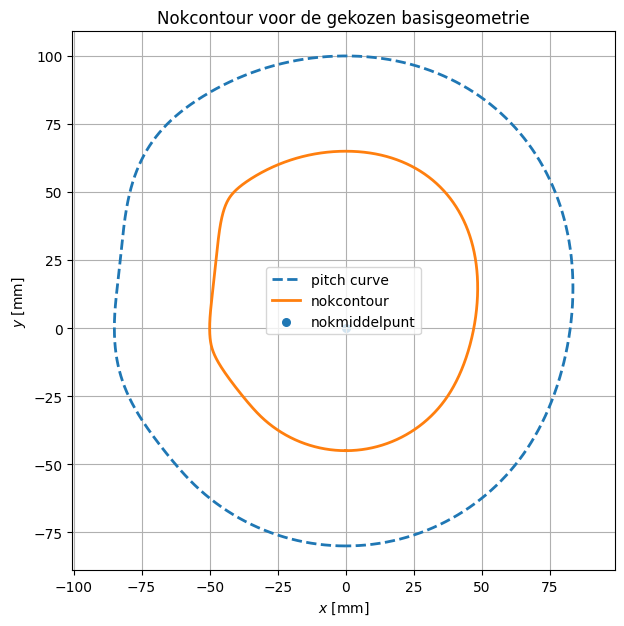

In [170]:
def plot_cam_contour(base_radius, follower_radius, eccentricity, theta, lift, pressure_angle):
    d = np.sqrt((base_radius + follower_radius)**2 - eccentricity**2)

    lambda_angle = -theta - np.arctan2(eccentricity, d + lift) + np.pi / 2

    x_pitch = -np.cos(lambda_angle) * np.sqrt((d + lift)**2 + eccentricity**2)
    y_pitch = -np.sin(lambda_angle) * np.sqrt((d + lift)**2 + eccentricity**2)

    x_cam = x_pitch - follower_radius * np.cos(-theta + pressure_angle + 3*np.pi/2)
    y_cam = y_pitch - follower_radius * np.sin(-theta + pressure_angle + 3*np.pi/2)

    plt.figure(figsize=(7, 7))
    plt.plot(x_pitch, y_pitch, linestyle="--", linewidth=2, label="pitch curve")
    plt.plot(x_cam, y_cam, linewidth=2, label="nokcontour")
    plt.scatter(0, 0, s=30, label="nokmiddelpunt")
    plt.xlabel("$x$ [mm]")
    plt.ylabel("$y$ [mm]")
    plt.title("Nokcontour voor de gekozen basisgeometrie")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_cam_contour(
    base_radius,
    Rr,
    eccentricity_geometry,
    theta,
    lift,
    pressure_angle_geometry
)

De figuur toont de pitch curve en de effectieve nokcontour voor de gekozen basisgeometrie. De pitch curve is de baan van het middelpunt van de rolvolger. De nokcontour ligt één rolvolgerstraal $R_r$ naar binnen. Omdat eerder gecontroleerd werd dat $\rho_{\text{pitch,min}} > R_r$, verwachten we geen ondersnijding.

<a id="referenties"></a>
# 6. Referenties

<a id="ref1"></a>
[1] Research article die wall friction: https://www.sciencedirect.com/science/article/pii/0032591083870090?fr=RR-2&ref=pdf_download&rr=a0f3901e18301327

<a id="ref2"></a>
[2] Krachten bij tablet compressie: https://www.scribd.com/document/879454686/Various-Forces-in-the-Compression

<a id="ref3"></a>
[3] Tablet compression force: https://www.futek.com/applications/pill-press-force-verification

<a id="ref4"></a>
[4] How tablet compression works: https://www.abbviecontractmfg.com/news-and-insights/fun-science-friday/tableting-vs-encapsulation.html

<a id="ref5"></a>
[5] Voorbeeld tablet copression machine: https://nl.achievechem.com/tablet-press-machines/pill-maker-machine.html

<a id="ref6"></a>
[6] Gif tablet compressie nokkenband: https://en.wikipedia.org/wiki/File:Tablet_press_animation.gif
